# CMIP6 - Climate Warming Pattern Analysis

In [ ]:
import intake
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs

from cmip_analysis import (reshape_by_year, 
                           prepare_variable,
                           calculate_quantiles,
                           calculate_warming_slopes, 
                           prepare_spatial_data,
                           fit_kmeans,
                           calculate_wcss,
                           calculate_cluster_areas)

### 1. CMIP6 Data

In [2]:
catalog_url = "https://raw.githubusercontent.com/NCAR/intake-esm-datastore/master/catalogs/pangeo-cmip6.json"

catalog = intake.open_esm_datastore(catalog_url)
catalog.df.columns

Index(['activity_id', 'institution_id', 'source_id', 'experiment_id',
       'member_id', 'table_id', 'variable_id', 'grid_label', 'zstore',
       'dcpp_init_year', 'version'],
      dtype='str')

In [3]:
catalog

,unique
activity_id,18
institution_id,36
source_id,88
experiment_id,170
member_id,657
table_id,37
variable_id,700
grid_label,10
zstore,514818
dcpp_init_year,61


### 2. Analysis of Historical Patterns - CMIP6_NOAA_historical (1948-2014)

#### 2.1. Getting the Data

In [4]:
hist_search = catalog.search(table_id='3hr', 
                             variable_id='tas',
                             institution_id='NOAA-GFDL',
                             experiment_id='esm-hist',
                             source_id='GFDL-ESM4')

In [5]:
hist_datasets = hist_search.to_dataset_dict()
print(hist_datasets.keys())


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 03:42&lt;00:00]</div>

dict_keys(['CMIP.NOAA-GFDL.GFDL-ESM4.esm-hist.3hr.gr1'])


In [6]:
ds_hist = hist_datasets['CMIP.NOAA-GFDL.GFDL-ESM4.esm-hist.3hr.gr1']
ds_hist

<xarray.Dataset> Size: 100GB
Dimensions:         (member_id: 1, dcpp_init_year: 1, time: 481800, lat: 180,
                     lon: 288, bnds: 2)
Coordinates:
  * member_id       (member_id) object 8B 'r1i1p1f1'
  * dcpp_init_year  (dcpp_init_year) float64 8B nan
  * time            (time) object 4MB 1850-01-01 03:00:00 ... 2015-01-01 00:0...
  * lat             (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon             (lon) float64 2kB 0.625 1.875 3.125 ... 356.9 358.1 359.4
    lat_bnds        (lat, bnds) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    lon_bnds        (lon, bnds) float64 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    height          float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    tas             (member_id, dcpp_init_year, time, lat, lon) float32 100GB dask.array<chunksize=(1, 1, 415, 180, 288), meta=np.ndarray>
Attributes: (12/60)
    Conventions:                      CF-1.7 CMIP-6.0 UGRID-1.0
    activity_id:                      CMIP
    branch_method:                    standard
    branch_time_in_child:             0.0
    branch_time_in_parent:            36500.0
    comment:                          <null ref>
    ...                               ...
    intake_esm_attrs:variable_id:     tas
    intake_esm_attrs:grid_label:      gr1
    intake_esm_attrs:zstore:          gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ES...
    intake_esm_attrs:version:         20180701
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.NOAA-GFDL.GFDL-ESM4.esm-hist.3hr.gr1

#### 2.2. Data Pre-Processing

In [7]:
# The dataset contains 165 years: 1850 through 2014 inclusive.
ds_hist = reshape_by_year(ds_hist, 1850, 2015)
tas_hist = prepare_variable(ds_hist, 'tas')

tas_hist = tas_hist.chunk({'year': 1, 'time': -1, 'lat': -1, 'lon': -1})
tas_hist

<xarray.DataArray 'tas' (year: 165, time: 2920, lat: 180, lon: 288)> Size: 100GB
dask.array<rechunk-merge, shape=(165, 2920, 180, 288), dtype=float32, chunksize=(1, 2920, 180, 288), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
  * time     (time) int64 23kB 0 1 2 3 4 5 6 ... 2914 2915 2916 2917 2918 2919
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
    height   float64 8B ...
Attributes:
    cell_measures:  area: areacella
    cell_methods:   area: mean time: point
    interp_method:  conserve_order2
    long_name:      Near-Surface Air Temperature
    original_name:  tas
    standard_name:  air_temperature
    units:          K

#### 2.3. Obtaining Annual Air Temperature Quantiles Over the Years 1948–2014

In [8]:
# Restrict the  analysis to 1948–2014.
tas_hist  = tas_hist.sel(year=slice(1948, 2014))
tas_hist

<xarray.DataArray 'tas' (year: 67, time: 2920, lat: 180, lon: 288)> Size: 41GB
dask.array<getitem, shape=(67, 2920, 180, 288), dtype=float32, chunksize=(1, 2920, 180, 288), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 536B 1948 1949 1950 1951 1952 ... 2011 2012 2013 2014
  * time     (time) int64 23kB 0 1 2 3 4 5 6 ... 2914 2915 2916 2917 2918 2919
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
    height   float64 8B ...
Attributes:
    cell_measures:  area: areacella
    cell_methods:   area: mean time: point
    interp_method:  conserve_order2
    long_name:      Near-Surface Air Temperature
    original_name:  tas
    standard_name:  air_temperature
    units:          K

In [9]:
quantiles_hist = calculate_quantiles(tas_hist)
quantiles_hist = quantiles_hist.chunk({'quantile': 1, 'year': 1, 'lat': -1, 'lon': -1})
quantiles_hist

<xarray.DataArray 'tas' (quantile: 101, year: 67, lat: 180, lon: 288)> Size: 3GB
dask.array<rechunk-merge, shape=(101, 67, 180, 288), dtype=float64, chunksize=(1, 1, 180, 288), chunktype=numpy.ndarray>
Coordinates:
  * quantile  (quantile) float64 808B 0.0 0.01 0.02 0.03 ... 0.97 0.98 0.99 1.0
  * year      (year) int64 536B 1948 1949 1950 1951 1952 ... 2011 2012 2013 2014
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
Attributes:
    cell_measures:  area: areacella
    cell_methods:   area: mean time: point
    interp_method:  conserve_order2
    long_name:      Near-Surface Air Temperature
    original_name:  tas
    standard_name:  air_temperature
    units:          K

#### 2.4. Calculating Warming Rates of Annual Air Temperature Quantiles Across the Globe

In [10]:
slopes_hist = calculate_warming_slopes(quantiles_hist)
slopes_hist

<xarray.DataArray (quantile: 101, lat: 180, lon: 288)> Size: 42MB
dask.array<truediv, shape=(101, 180, 288), dtype=float64, chunksize=(1, 180, 288), chunktype=numpy.ndarray>
Coordinates:
  * quantile  (quantile) float64 808B 0.0 0.01 0.02 0.03 ... 0.97 0.98 0.99 1.0
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
Attributes:
    cell_measures:  area: areacella
    cell_methods:   area: mean time: point
    interp_method:  conserve_order2
    long_name:      Near-Surface Air Temperature
    original_name:  tas
    standard_name:  air_temperature
    units:          K

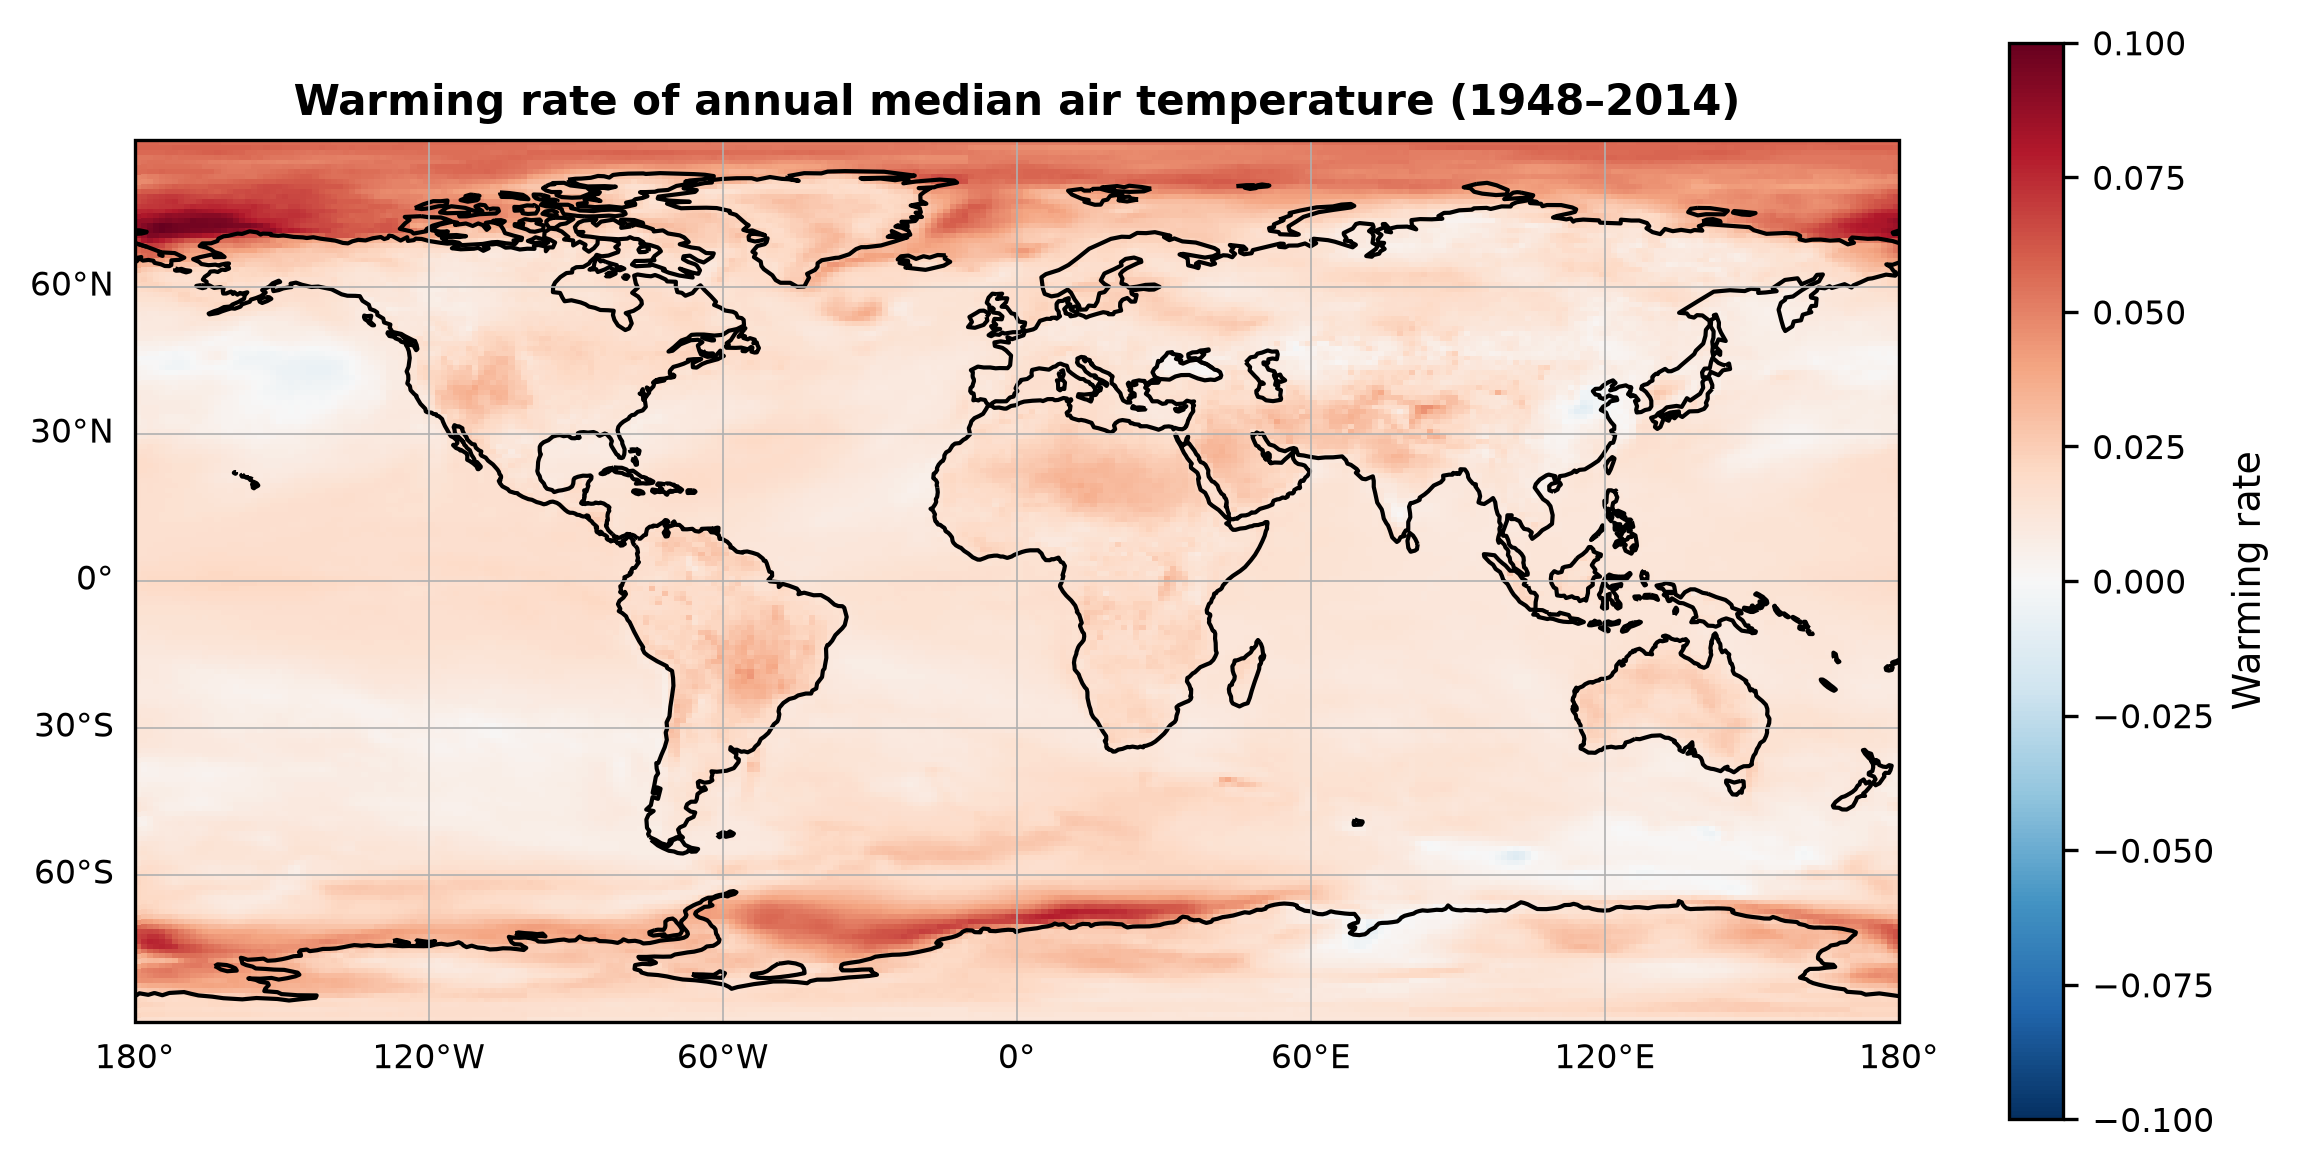

In [ ]:
# Warming rate of annual median air temperature (q=0.5)
fig = plt.figure(figsize=(8, 4), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

im = slopes_hist.sel(quantile=0.5).plot(ax=ax,
                                        transform=ccrs.PlateCarree(),
                                        norm=colors.Normalize(vmin=-0.1, vmax=0.1))

cbar = im.colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Warming rate", fontsize=9)

ax.coastlines()
gl = ax.gridlines(draw_labels={"bottom": True, "left": True, "top": False, "right": False},
                  linewidth=0.4, xlabel_style={"size": 8}, ylabel_style={"size": 8})

ax.set_title("Warming rate of annual median air temperature (1948–2014)",
             fontsize=10,
             fontweight="bold")
plt.tight_layout()

In [ ]:
slope_values_hist, coordinates_hist = prepare_spatial_data(slopes_hist)
slope_values_hist.shape, coordinates_hist.shape

((51840, 101), (51840, 2))

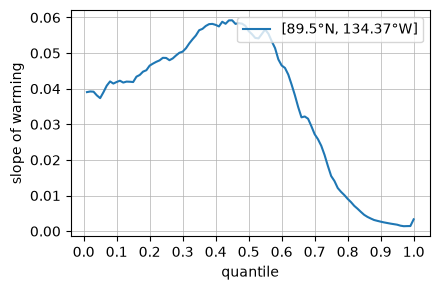

In [13]:
# Quantile warming-rates near the North Pole
fig, ax = plt.subplots(figsize=(4.5, 3))
xaxis = np.linspace(0.01, 1.0, 100)
ax.plot(xaxis, slope_values_hist[51732, 1:])
ax.set_ylabel("slope of warming", fontsize=10)
ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.grid(which="major", axis="x", linewidth=0.5)
ax.grid(which="major", axis="y", linewidth=0.5)
ax.legend(["[89.5°N, 134.37°W]"], fontsize=10, loc="upper right")
ax.set_xlabel("quantile", fontsize=10)
plt.tight_layout()

Text(0.5, 0, 'quantile')

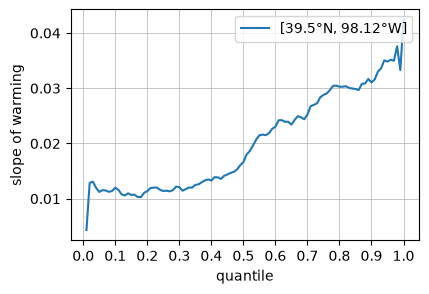

In [14]:
# Quantile warming-rates in the center of the U.S.
fig, ax = plt.subplots(figsize=(4.5, 3))
xaxis = np.linspace(0.01, 1.0, 100)
ax.plot(xaxis, slope_values_hist[37361, 1:])
ax.set_ylabel("slope of warming", fontsize=10)
ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.grid(which="major", axis="x", linewidth=0.5)
ax.grid(which="major", axis="y", linewidth=0.5)
ax.legend(["[39.5°N, 98.12°W]"], fontsize=10, loc="upper right")
ax.set_xlabel("quantile", fontsize=10)

#### 2.5. K-Means Clustering

##### 2.5.1. Identifying Optimal Number of Clusters

In [15]:
cluster_range = range(2, 50)
wcss_hist = calculate_wcss(slope_values_hist, cluster_range)

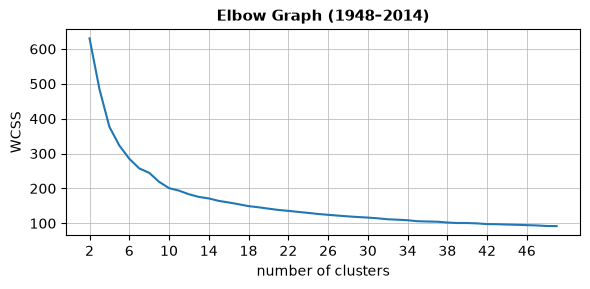

In [16]:
fig, ax = plt.subplots(figsize=(6, 3))
xaxis = np.arange(2, 50)
ax.plot(xaxis, wcss_hist)
ax.set_ylabel("WCSS", fontsize=10)
ax.set_xticks(np.arange(2, 50, 4))
ax.set_xlabel("number of clusters", fontsize=10)
ax.grid(which="major", axis="x", linewidth=0.5)
ax.grid(which="major", axis="y", linewidth=0.5)
ax.set_title("Elbow Graph (1948–2014)", fontsize=11, fontweight="bold")
plt.tight_layout()

##### 2.5.2. Performing Clustering

In [17]:
n_clusters = 6
model_hist, labels_hist = fit_kmeans(slope_values_hist, n_clusters=n_clusters)

coordinates_hist["cluster"] = labels_hist

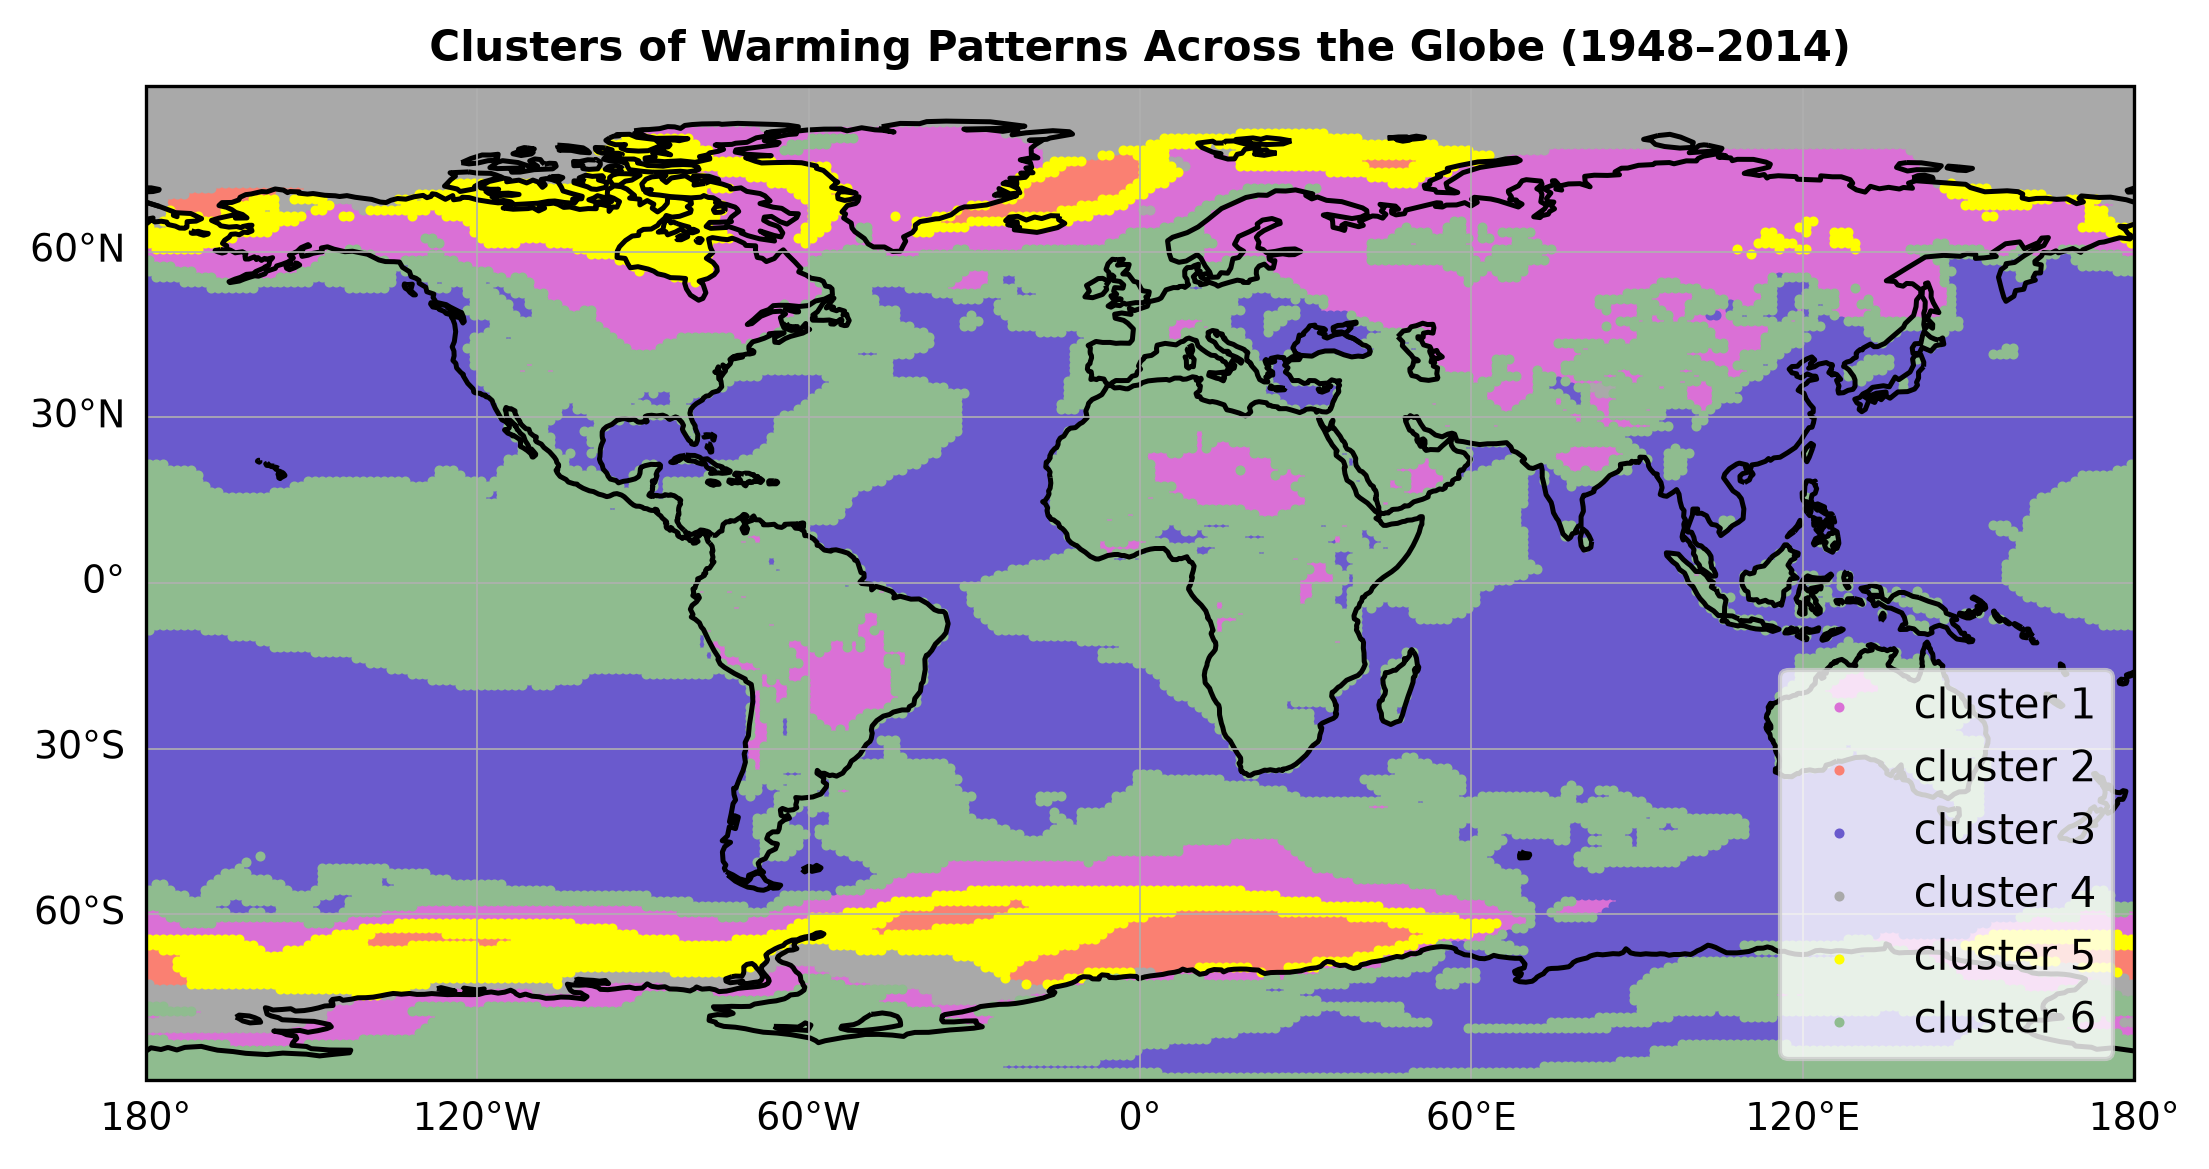

In [18]:
cluster_colors = ["orchid", "salmon", "slateblue", "darkgrey", "yellow", "darkseagreen"]

fig = plt.figure(figsize=(8, 4), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

for cluster in range(n_clusters):
    subset = coordinates_hist.loc[coordinates_hist["cluster"] == cluster]
    ax.scatter(subset["lon"], subset["lat"], marker="o", s=2, 
               c=cluster_colors[cluster], label=f"cluster {cluster + 1}")

ax.coastlines(linewidth=1.2)

ax.legend(loc="lower right")
ax.set_title("Clusters of Warming Patterns Across the Globe (1948–2014)", 
             fontsize=10, fontweight="bold")

gl = ax.gridlines(draw_labels={"bottom": True, "left": True, "top": False, "right": False},
                  linewidth=0.4, xlabel_style={"size": 9}, ylabel_style={"size": 9})

plt.tight_layout()

##### 2.5.3. Calculating Area of Each Cluster

In [19]:
areas_hist = calculate_cluster_areas(slopes_hist, coordinates_hist, labels_hist, n_clusters)

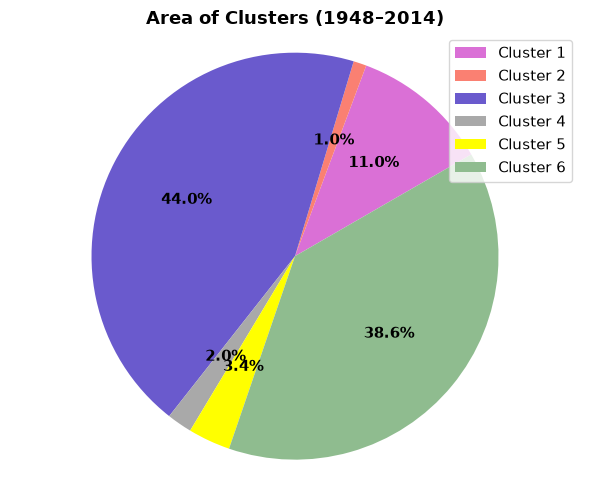

In [20]:
cluster_labels = [f"Cluster {i}" for i in range(1, n_clusters + 1)]

plt.figure(figsize=(6, 5))
plt.pie(areas_hist, colors=cluster_colors, autopct="%1.1f%%", startangle=30, 
        textprops={"color": "black", "weight": "bold", "fontsize": 11})
plt.legend(cluster_labels, loc="upper right", fontsize=11)
plt.axis("equal")
plt.title("Area of Clusters (1948–2014)", fontsize=13, fontweight="bold")
plt.tight_layout()

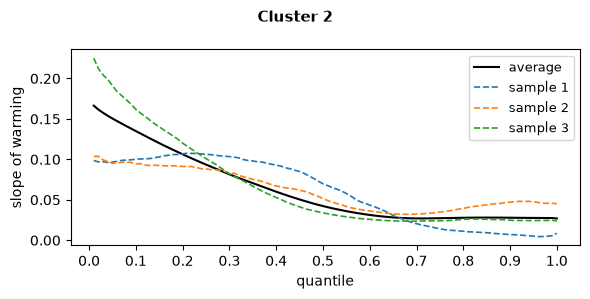

In [21]:
# Example cluster-pattern profile: Cluster 2
cluster_2 = coordinates_hist.loc[coordinates_hist["cluster"] == 1]

fig, ax = plt.subplots(figsize=(6, 3))
xaxis = np.linspace(0.01, 1.0, 100)

ax.plot(xaxis, np.mean(slope_values_hist[cluster_2.index, :], axis=0)[1:], 
        color="black")
ax.set_ylabel("slope of warming", fontsize=10)
ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.set_xlabel("quantile", fontsize=10)

ax.plot(xaxis, slope_values_hist[5041, 1:], linestyle="--", linewidth=1.2)
ax.plot(xaxis, slope_values_hist[48380, 1:], linestyle="--", linewidth=1.2)
ax.plot(xaxis, slope_values_hist[7497, 1:], linestyle="--", linewidth=1.2)

ax.legend(["average", "sample 1", "sample 2", "sample 3"],
          fontsize=9, loc="upper right")
fig.suptitle("Cluster 2", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.grid(False)

### 3. Analysis of Future Patterns - CMIP6_NOAA_future (2015-2100)

#### 3.1. Getting the Data

In [22]:
future_search = catalog.search(table_id='3hr', 
                               variable_id='tas', 
                               institution_id='NOAA-GFDL', 
                               experiment_id='ssp126', 
                               source_id='GFDL-ESM4')

In [23]:
futute_datasets = future_search.to_dataset_dict()
print(futute_datasets.keys())


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 03:18&lt;00:00]</div>

dict_keys(['ScenarioMIP.NOAA-GFDL.GFDL-ESM4.ssp126.3hr.gr1'])


In [24]:
ds_future = futute_datasets['ScenarioMIP.NOAA-GFDL.GFDL-ESM4.ssp126.3hr.gr1']
ds_future

<xarray.Dataset> Size: 52GB
Dimensions:         (member_id: 1, dcpp_init_year: 1, time: 251120, lat: 180,
                     lon: 288, bnds: 2)
Coordinates:
  * member_id       (member_id) object 8B 'r1i1p1f1'
  * dcpp_init_year  (dcpp_init_year) float64 8B nan
  * time            (time) object 2MB 2015-01-01 03:00:00 ... 2101-01-01 00:0...
  * lat             (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon             (lon) float64 2kB 0.625 1.875 3.125 ... 356.9 358.1 359.4
    lat_bnds        (lat, bnds) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    lon_bnds        (lon, bnds) float64 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    height          float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    tas             (member_id, dcpp_init_year, time, lat, lon) float32 52GB dask.array<chunksize=(1, 1, 417, 180, 288), meta=np.ndarray>
Attributes: (12/60)
    Conventions:                      CF-1.7 CMIP-6.0 UGRID-1.0
    activity_id:                      ScenarioMIP
    branch_method:                    standard
    branch_time_in_child:             60225.0
    branch_time_in_parent:            60225.0
    comment:                          <null ref>
    ...                               ...
    intake_esm_attrs:variable_id:     tas
    intake_esm_attrs:grid_label:      gr1
    intake_esm_attrs:zstore:          gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/...
    intake_esm_attrs:version:         20180701
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           ScenarioMIP.NOAA-GFDL.GFDL-ESM4.ssp126....

#### 3.2. Data Pre-Processing

In [25]:
# The dataset contains 85 years: 2015 through 2100 inclusive.
ds_future = reshape_by_year(ds_future, 2015, 2101)
tas_future = prepare_variable(ds_future, 'tas')

tas_future = tas_future.chunk({'year': 1, 'time': -1, 'lat': -1, 'lon': -1})
tas_future

<xarray.DataArray 'tas' (year: 86, time: 2920, lat: 180, lon: 288)> Size: 52GB
dask.array<rechunk-merge, shape=(86, 2920, 180, 288), dtype=float32, chunksize=(1, 2920, 180, 288), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 688B 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
  * time     (time) int64 23kB 0 1 2 3 4 5 6 ... 2914 2915 2916 2917 2918 2919
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
    height   float64 8B ...
Attributes:
    cell_measures:  area: areacella
    cell_methods:   area: mean time: point
    interp_method:  conserve_order2
    long_name:      Near-Surface Air Temperature
    original_name:  tas
    standard_name:  air_temperature
    units:          K

#### 3.3. Obtaining Annual Air Temprature Quantiles Over the Years 2015-2100

In [26]:
quantiles_future = calculate_quantiles(tas_future)
quantiles_future = quantiles_future.chunk({'quantile': 1, 'year': 1, 'lat': -1, 'lon': -1})
quantiles_future

<xarray.DataArray 'tas' (quantile: 101, year: 86, lat: 180, lon: 288)> Size: 4GB
dask.array<rechunk-merge, shape=(101, 86, 180, 288), dtype=float64, chunksize=(1, 1, 180, 288), chunktype=numpy.ndarray>
Coordinates:
  * quantile  (quantile) float64 808B 0.0 0.01 0.02 0.03 ... 0.97 0.98 0.99 1.0
  * year      (year) int64 688B 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
Attributes:
    cell_measures:  area: areacella
    cell_methods:   area: mean time: point
    interp_method:  conserve_order2
    long_name:      Near-Surface Air Temperature
    original_name:  tas
    standard_name:  air_temperature
    units:          K

#### 3.4. Calculating Warming Rates of Annual Air Temperature Quantiles Across the Globe

In [27]:
slopes_future = calculate_warming_slopes(quantiles_future)
slopes_future

<xarray.DataArray (quantile: 101, lat: 180, lon: 288)> Size: 42MB
dask.array<truediv, shape=(101, 180, 288), dtype=float64, chunksize=(1, 180, 288), chunktype=numpy.ndarray>
Coordinates:
  * quantile  (quantile) float64 808B 0.0 0.01 0.02 0.03 ... 0.97 0.98 0.99 1.0
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 2kB 0.625 1.875 3.125 4.375 ... 356.9 358.1 359.4
Attributes:
    cell_measures:  area: areacella
    cell_methods:   area: mean time: point
    interp_method:  conserve_order2
    long_name:      Near-Surface Air Temperature
    original_name:  tas
    standard_name:  air_temperature
    units:          K

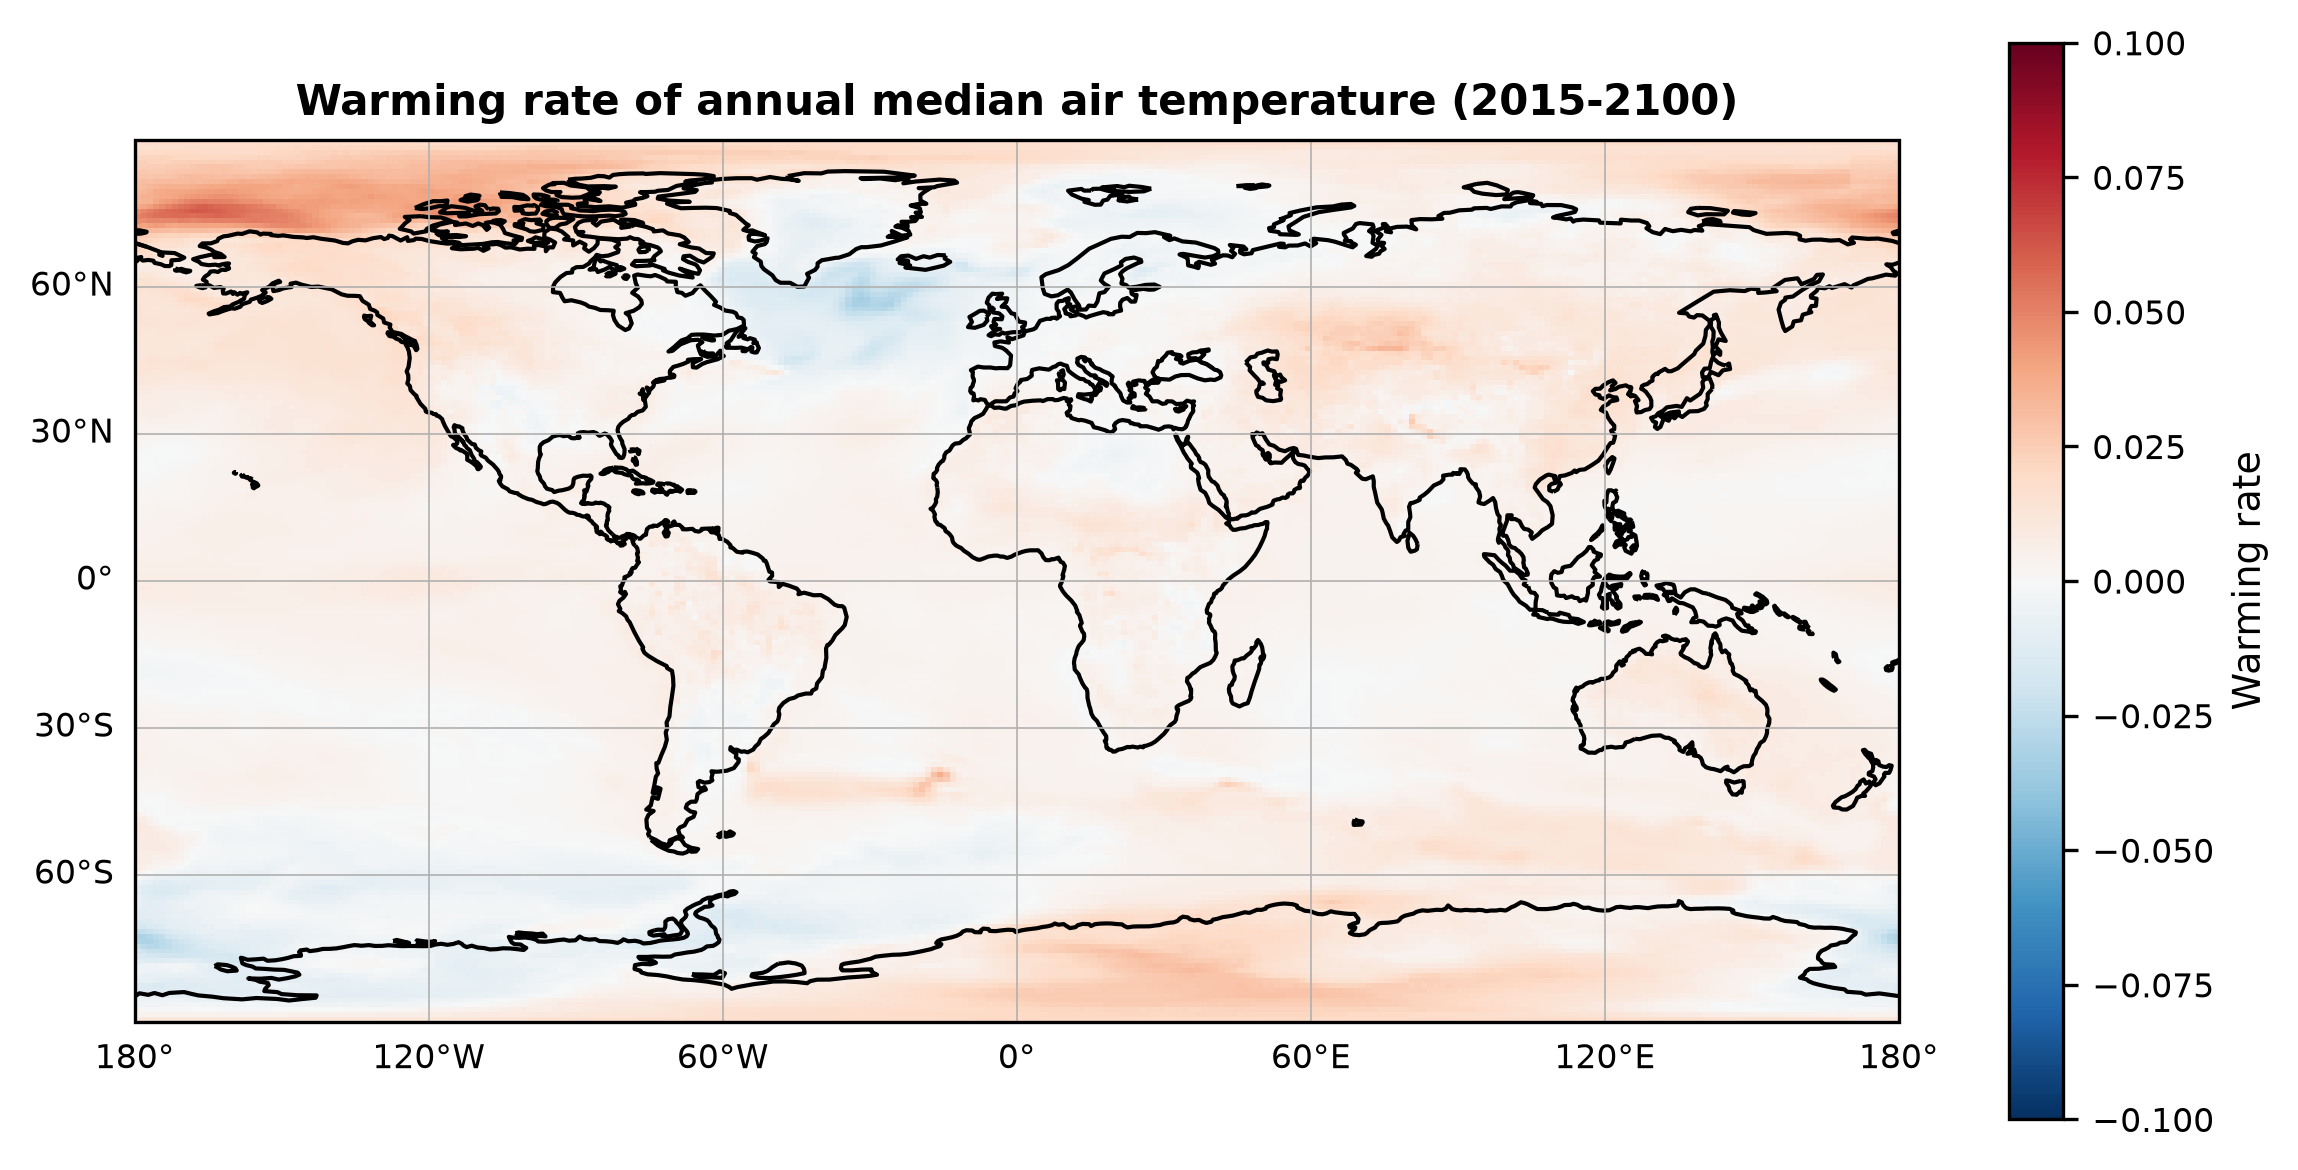

In [ ]:
# Warming rate of annual median air temperature (q=0.5)
fig = plt.figure(figsize=(8, 4), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

im = slopes_future.sel(quantile=0.5).plot(ax=ax,
                                        transform=ccrs.PlateCarree(),
                                        norm=colors.Normalize(vmin=-0.1, vmax=0.1))

cbar = im.colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Warming rate", fontsize=9)

ax.coastlines()
gl = ax.gridlines(draw_labels={"bottom": True, "left": True, "top": False, "right": False},
                  linewidth=0.4, xlabel_style={"size": 8}, ylabel_style={"size": 8})

ax.set_title("Warming rate of annual median air temperature (2015-2100)",
             fontsize=10,
             fontweight="bold")
plt.tight_layout()

In [ ]:
slope_values_future, coordinates_future = prepare_spatial_data(slopes_future)
slope_values_future.shape, coordinates_future.shape

((51840, 101), (51840, 2))

#### 3.5. K-Means Clustering

##### 3.5.1. Identifying Optimal Number of Clusters

In [30]:
cluster_range = range(2, 50)
wcss_future = calculate_wcss(slope_values_future, cluster_range)

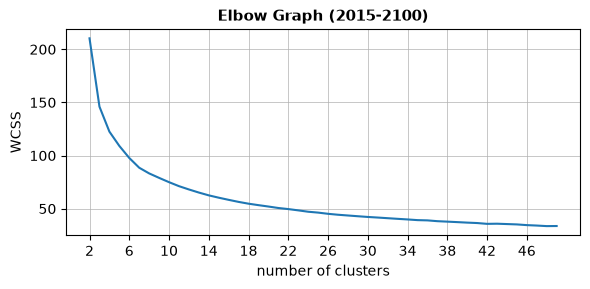

In [31]:
fig, ax = plt.subplots(figsize=(6, 3))
xaxis = np.arange(2, 50)
ax.plot(xaxis, wcss_future)
ax.set_ylabel("WCSS", fontsize=10)
ax.set_xticks(np.arange(2, 50, 4))
ax.set_xlabel("number of clusters", fontsize=10)
ax.grid(which="major", axis="x", linewidth=0.5)
ax.grid(which="major", axis="y", linewidth=0.5)
ax.set_title("Elbow Graph (2015-2100)", fontsize=11, fontweight="bold")
plt.tight_layout()

#### 3.5.2. Performing Clustering

In [32]:
n_clusters = 6
model_future, labels_future = fit_kmeans(slope_values_future, n_clusters=n_clusters)

coordinates_future["cluster"] = labels_future

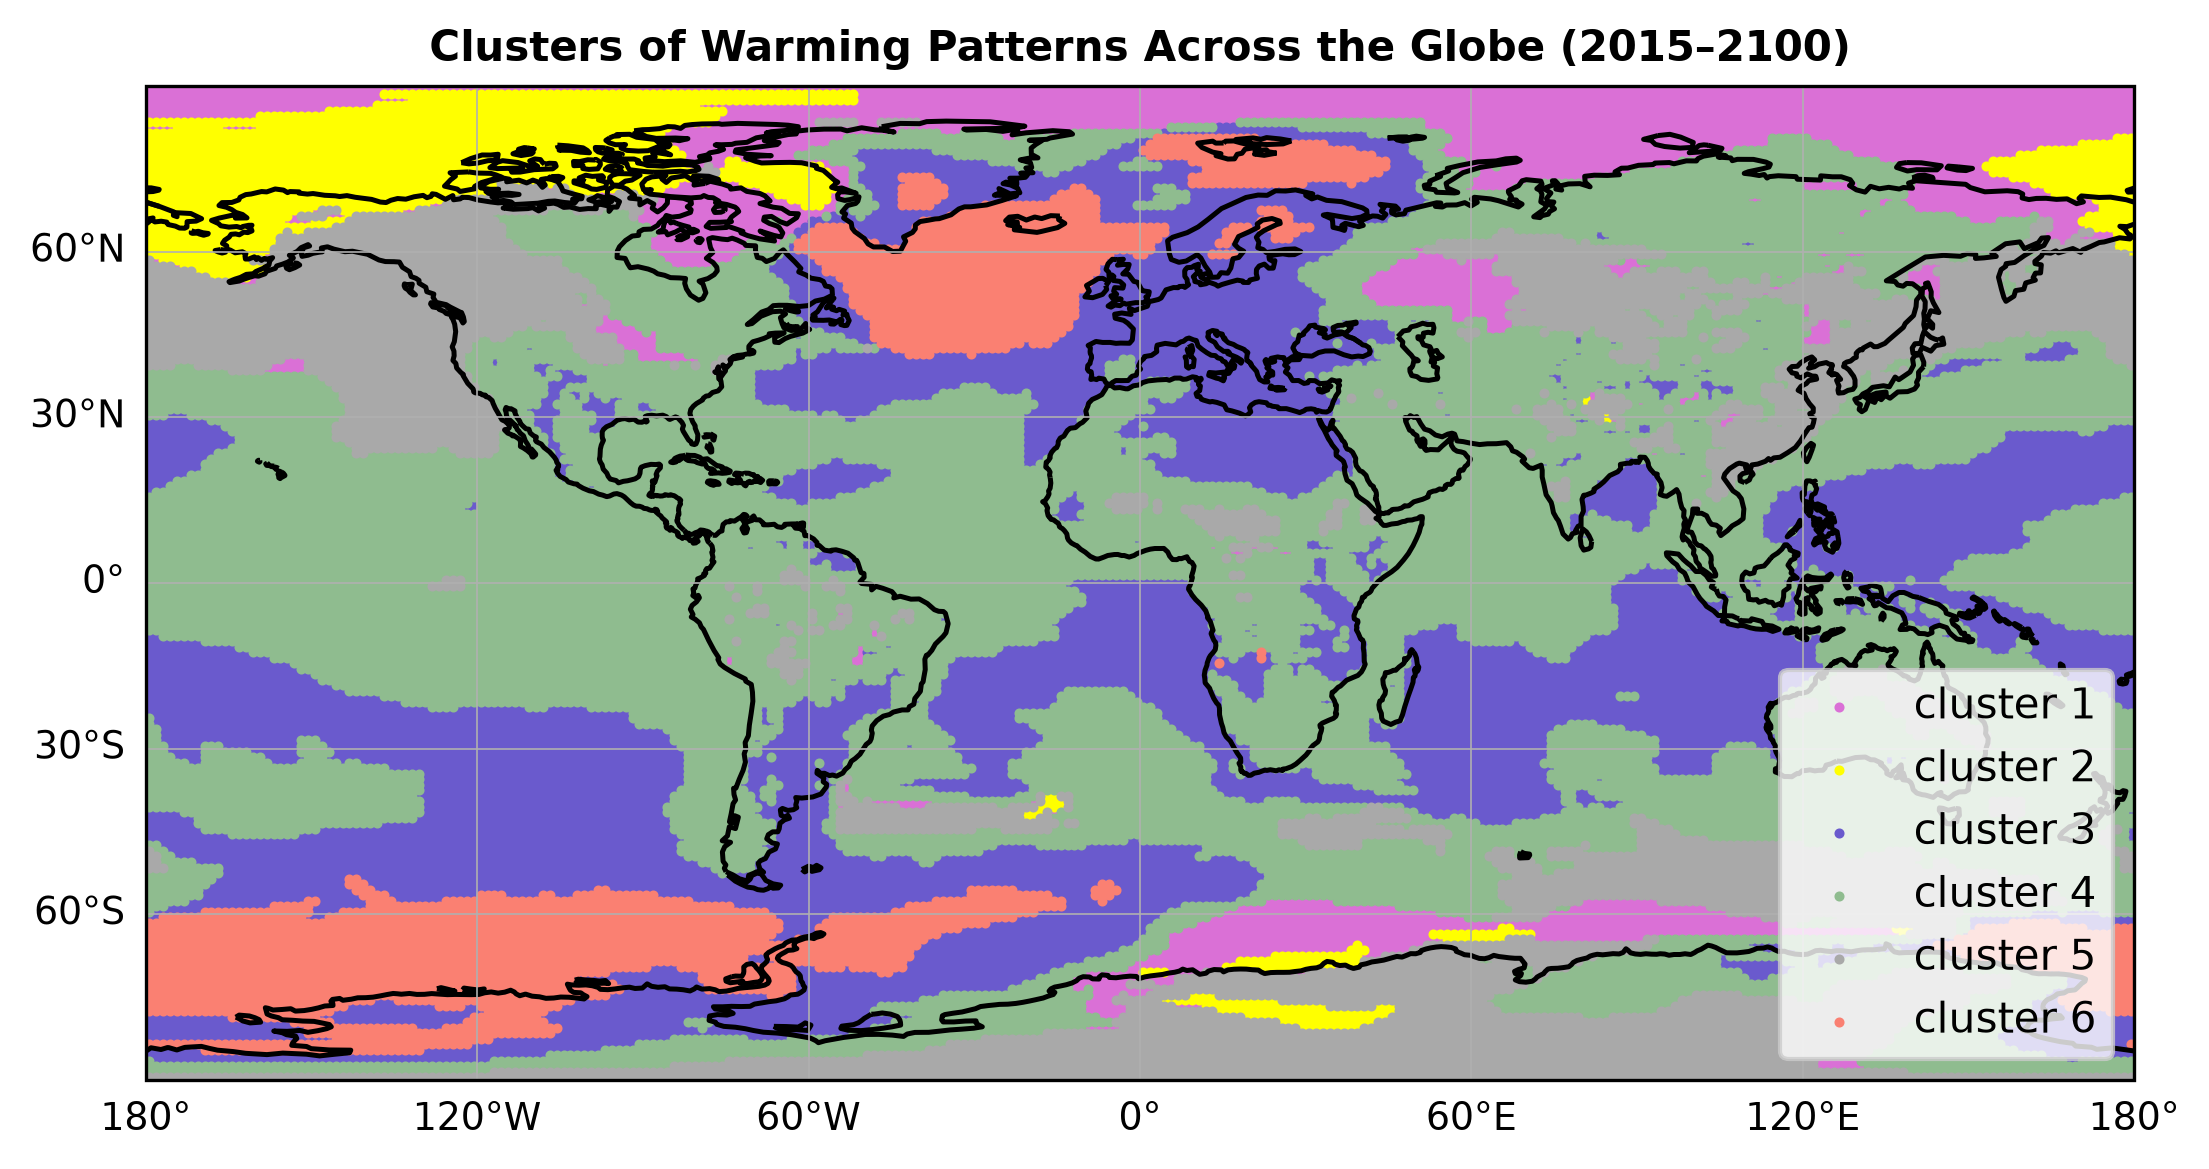

In [33]:
cluster_colors = ["orchid", "yellow", "slateblue", "darkseagreen", "darkgrey", "salmon"]

fig = plt.figure(figsize=(8, 4), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

for cluster in range(n_clusters):
    subset = coordinates_future.loc[coordinates_future["cluster"] == cluster]
    ax.scatter(subset["lon"], subset["lat"], marker="o", s=2, 
               c=cluster_colors[cluster], label=f"cluster {cluster + 1}")

ax.coastlines(linewidth=1.2)

ax.legend(loc="lower right")
ax.set_title("Clusters of Warming Patterns Across the Globe (2015–2100)", 
             fontsize=10, fontweight="bold")

gl = ax.gridlines(draw_labels={"bottom": True, "left": True, "top": False, "right": False},
                  linewidth=0.4, xlabel_style={"size": 9}, ylabel_style={"size": 9})

plt.tight_layout()

##### 3.5.3. Obtaining Area of Each Cluster

In [34]:
areas_future = calculate_cluster_areas(slopes_future, coordinates_future, labels_future, n_clusters)

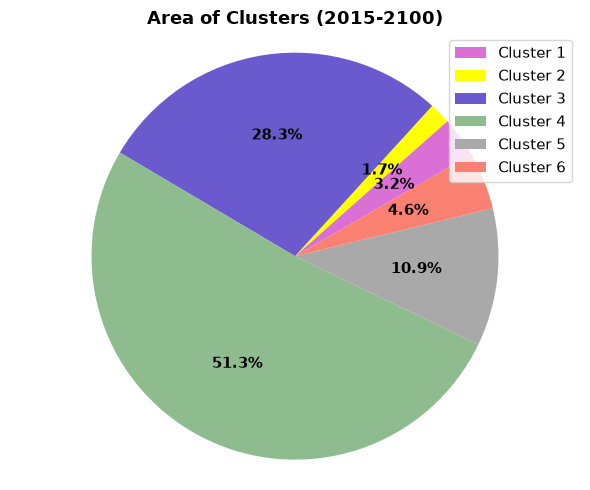

In [35]:
cluster_labels = [f"Cluster {i}" for i in range(1, n_clusters + 1)]

plt.figure(figsize=(6, 5))
plt.pie(areas_future, colors=cluster_colors, autopct="%1.1f%%", startangle=30, 
        textprops={"color": "black", "weight": "bold", "fontsize": 11})
plt.legend(cluster_labels, loc="upper right", fontsize=11)
plt.axis("equal")
plt.title("Area of Clusters (2015-2100)", fontsize=13, fontweight="bold")
plt.tight_layout()